In [1]:
# Create the Spark Session
from pyspark.sql import SparkSession
from pyspark.streaming import StreamingContext
from pyspark.sql.functions import *
#from pyspark.sql.window import Window
from pyspark.sql.functions import split, window, current_timestamp
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans
from pyspark.ml.regression import LinearRegression
import matplotlib.pyplot as plt

spark = (
    SparkSession 
    .builder 
    .appName("Boarding Bus Stream Data Analysis") 
    .config("spark.streaming.stopGracefullyOnShutdown", True) 
    .config('spark.jars.packages', 'org.apache.spark:spark-sql-kafka-0-10_2.12:3.3.0')
    .config("spark.sql.shuffle.partitions", 4)
    .master("local[*]") 
    .getOrCreate()
)

spark

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import from_json, col
from pyspark.sql.types import StructType, StringType, TimestampType, IntegerType

# Define schema matching boarding data
schema = StructType() \
  .add("PassengerId", StringType()) \
  .add("BoardingTime", TimestampType()) \
  .add("BusStopId", StringType()) \
  .add("TripId", StringType()) \
  .add("Sequence", StringType()) \
  .add("RouteId", StringType())

# Read from Kafka
stream_df = spark \
  .readStream \
  .format("kafka") \
  .option("kafka.bootstrap.servers", "ed-kafka:29092") \
  .option("subscribe", "boarding-data") \
  .option("startingOffset", "earliest") \
  .load() \
  .select(from_json(col("value").cast("string"), schema).alias("data")) \
  .select("data.*") \
  .withColumn("Hour", hour("BoardingTime")).withColumn("DayOfWeek", dayofweek("BoardingTime"))

<Figure size 640x480 with 0 Axes>

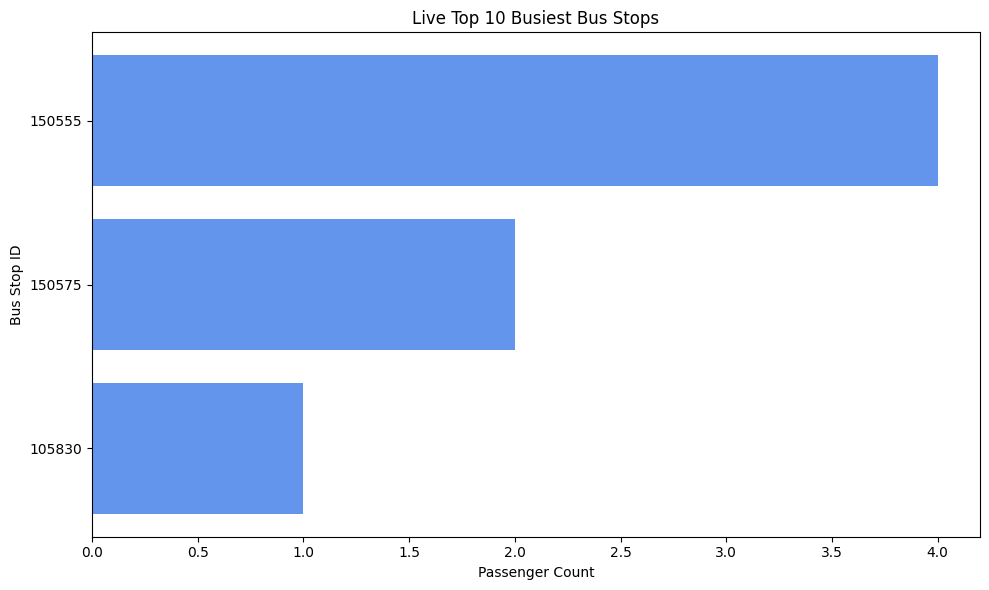

<Figure size 640x480 with 0 Axes>

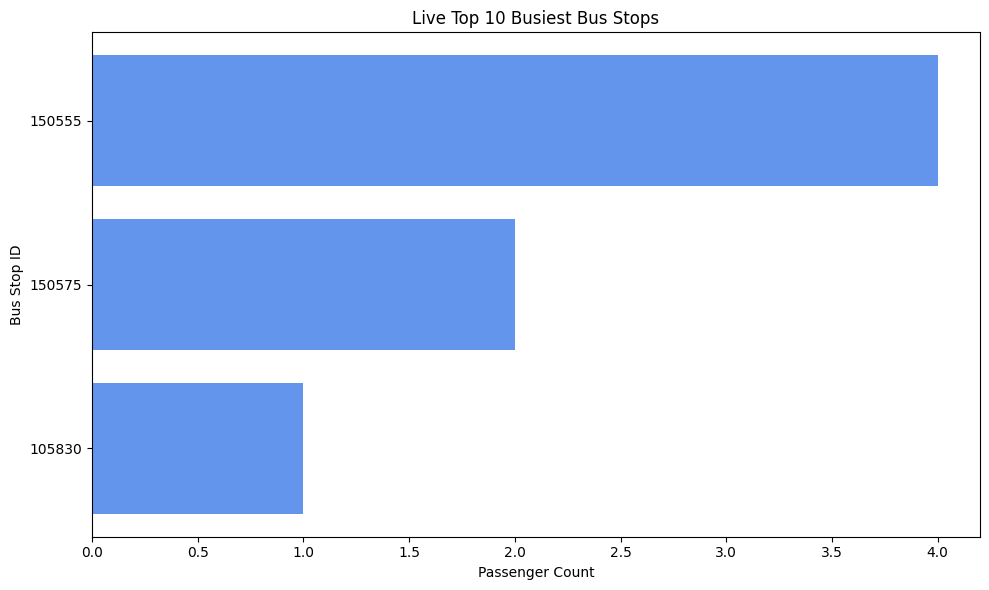

<Figure size 640x480 with 0 Axes>

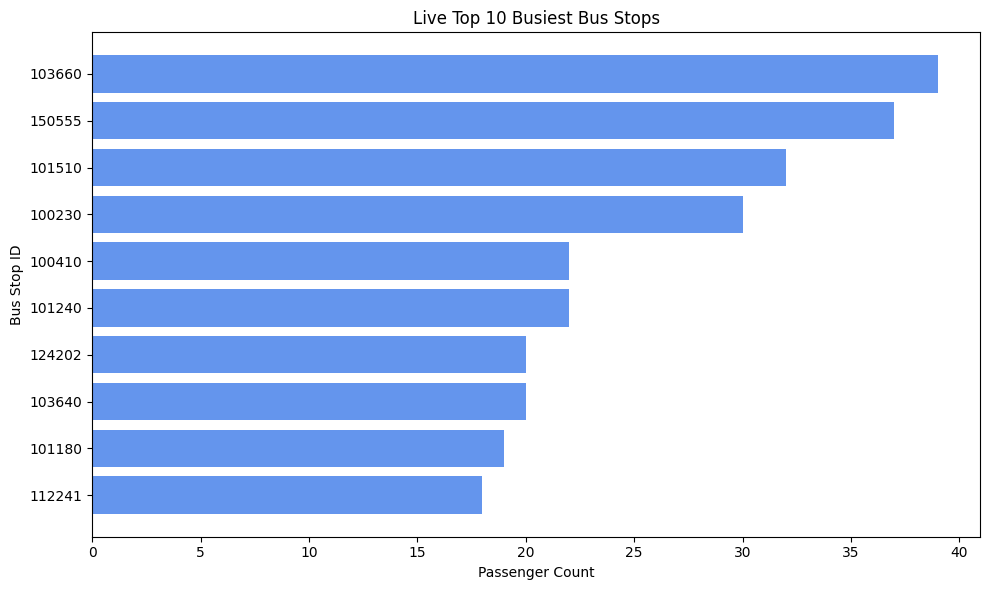

ERROR:root:Exception while sending command.
Traceback (most recent call last):
  File "/spark/python/lib/py4j-0.10.9.5-src.zip/py4j/clientserver.py", line 516, in send_command
    raise Py4JNetworkError("Answer from Java side is empty")
py4j.protocol.Py4JNetworkError: Answer from Java side is empty

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/spark/python/lib/py4j-0.10.9.5-src.zip/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/spark/python/lib/py4j-0.10.9.5-src.zip/py4j/clientserver.py", line 539, in send_command
    raise Py4JNetworkError(
py4j.protocol.Py4JNetworkError: Error while sending or receiving


Py4JError: An error occurred while calling o34.sql

In [3]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegressionModel
from pyspark.sql.window import Window

##1. BUS BUNCHING
df_with_watermark = stream_df.withWatermark("BoardingTime", "3 minutes")

# Self-join on BusStopId within 2 minutes, and different RouteId
bunching_df = df_with_watermark.alias("a") \
    .join(
        df_with_watermark.alias("b"),
        on=(
            (col("a.BusStopId") == col("b.BusStopId")) &
            (col("a.RouteId") != col("b.RouteId")) &
            (col("a.BoardingTime").between(col("b.BoardingTime") - expr("INTERVAL 2 MINUTES"),
                                           col("b.BoardingTime") + expr("INTERVAL 2 MINUTES")))
        )
    ) \
    .select(
        col("a.BusStopId").alias("BusStopId"),
        col("a.BoardingTime").alias("TimeA"),
        col("a.RouteId").alias("RouteA"),
        col("b.RouteId").alias("RouteB"),
        col("b.BoardingTime").alias("TimeB")
    ).dropDuplicates()

# Output to console
query1 = bunching_df.writeStream \
    .outputMode("append") \
    .format("console") \
    .option("truncate", False) \
    .start()

##4. TOP 10 BUSIEST BUSTOPS
top_bus_stops_df = stream_df.groupBy("BusStopId").count()

# Write to memory table for visualization
query2 = top_bus_stops_df.writeStream \
    .outputMode("complete") \
    .format("memory") \
    .trigger(processingTime = "5 minutes") \
    .queryName("top_bus_stops3") \
    .start()

plt.ion()  # Enable interactive mode

while True:
    time.sleep(300)  # Update interval

    # Query the memory table
    df = spark.sql("""
        SELECT BusStopId, count 
        FROM top_bus_stops3 
        ORDER BY count DESC 
        LIMIT 10
    """).toPandas()

    if not df.empty:
        plt.clf()
        plt.figure(figsize=(10, 6))
        plt.barh(df["BusStopId"].astype(str), df["count"], color='cornflowerblue')
        plt.xlabel("Passenger Count")
        plt.ylabel("Bus Stop ID")
        plt.title("Live Top 10 Busiest Bus Stops")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.pause(0.1)

# Apply watermark and time window to detect stops with no passenger activity
boardings_windowed = stream_df.withWatermark("BoardingTime", "5 minutes") \
    .groupBy(
        window(col("BoardingTime"), "5 minutes", "2 minutes"),
        col("BusStopId"),
        col("RouteId")
    ).agg(count("PassengerId").alias("boarding_count"))

# Filter for stops with 0 or low boardings (e.g., possible delays)
delayed_stops = boardings_windowed.filter(col("boarding_count") < 2)

# Output results to console (or can be saved to DB/alert system)
query3 = delayed_stops.writeStream \
    .outputMode("append") \
    .format("console") \
    .option("truncate", False) \
    .start()

## Anomaly Detection
watermarked_df = stream_df.withWatermark("BoardingTime", "10 minutes")

# Function for batch anomaly detection
def detect_anomalies(batch_df, batch_id):
    from pyspark.sql.functions import mean, stddev
    
    # Aggregate in this batch: group by window and BusStopId
    agg_df = batch_df.groupBy(
        window(col("BoardingTime"), "10 minutes"),
        col("BusStopId")
    ).count().withColumnRenamed("count", "boarding_count")
    
    # Compute mean and stddev across bus stops in the batch window
    stats_df = agg_df.agg(
        mean("boarding_count").alias("mean_count"),
        stddev("boarding_count").alias("std_dev")
    ).collect()[0]

    # Extract stats
    mean_count = stats_df["mean_count"]
    std_dev = stats_df["std_dev"]

    if std_dev is None or std_dev == 0:
        print("No variation in data this batch.")
        return

    # Calculate z-score and filter anomalies
    result_df = agg_df.withColumn(
        "z_score", (col("boarding_count") - mean_count) / std_dev
    ).filter(col("z_score") > 3)

    print(f"==== Detected Anomalies in Batch {batch_id} ====")
    result_df.show(truncate=False)

# Stream with foreachBatch
query4 = watermarked_df.writeStream \
    .outputMode("append") \
    .foreachBatch(detect_anomalies) \
    .start()

##PASSENGER COUNT PREDICTION
# Count passengers by time window for prediction
watermarked_df = stream_df.withWatermark("BoardingTime", "10 minutes")
# Feature engineering for real-time
agg_df = stream_df.groupBy(
    window(col("BoardingTime"), "10 minutes"),
    "Hour", "DayOfWeek", "BusStopId", "RouteId"
).count().withColumnRenamed("count", "PassengerCount")

def train_model(batch_df, batch_id):
    if batch_df.count() == 0:
        return
    
    print(f"Training on batch {batch_id}...")
    
    # Prepare features
    assembler = VectorAssembler(
        inputCols=["Hour", "DayOfWeek", "BusStopId", "RouteId"],
        outputCol="features"
    )
    vec_df = assembler.transform(batch_df)

    # Train model
    lr = LinearRegression(featuresCol="features", labelCol="PassengerCount")
    model = lr.fit(vec_df)

    # Save or use the model (optional)
    model.save(f"models/passenger_model_batch_{batch_id}")
    print(f"Model trained and saved for batch {batch_id}.")

# Trigger training for every 10-minute micro-batch
query5 = agg_df.writeStream \
    .outputMode("update") \
    .foreachBatch(train_model) \
    .trigger(processingTime="10 minutes") \
    .start()

query1.awaitTermination()
query2.awaitTermination()
query3.awaitTermination()
query4.awaitTermination()
query5.awaitTermination()
